# REVE LP → LoRA-FT — K-trials calibration sweep

Follows the REVE paper recipe (El Ouahidi et al. 2025, §3.3, [arxiv 2510.21585](https://arxiv.org/abs/2510.21585)) and the official `vendor/reve_eeg/src/downstream_tasks/train_core.py` / `models/lora.py` reference implementation, adapted to the K-trial calibration sweep this project cares about.

**Pipeline.**
1. **Stage 1 — Linear Probing on the source pool.** Freeze the encoder. Train only `cls_query_token` + `final_layer` (LayerNorm + Linear) on every non-held-out subject. Implements the `freeze_model` behaviour from `vendor/reve_eeg/src/utils/model_utils.py:42-47`. We cache encoder outputs once per subject (encoder is frozen, so the activations are constant during LP) and stream cached batches through the head — that's the only reason this is tractable on a laptop.
2. **Stage 2 — LoRA fine-tuning per (held-out subject, K).** Snapshot the LP model. For each (held-out subject, K) cell: restore the snapshot, inject LoRA adapters (rank `r`, alpha `alpha`) into the attention `to_qkv` and `to_out` projections of every transformer layer (matches `models/lora.get_lora_config` with `apply_to=["attention"]`), enable gradients on only the LoRA tensors + the head, fine-tune on the K-per-class calibration trials of that subject, evaluate on the remainder.

K-budget, held-out subject count, and LoRA hyperparameters are configurable below. Preprocessing matches `preprocessing/preprocessing_physio.py` (REVE-aligned).

## 0. Config

In [1]:
from __future__ import annotations

import sys, os, json, time, copy, math, fnmatch, warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- paths ---
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
EEGMMI_DIR = REPO_ROOT / "data" / "raw" / "eegmmi"
assert EEGMMI_DIR.exists(), f"missing dataset dir: {EEGMMI_DIR}"

# --- sweep config ---
K_BUDGETS         = (0, 1, 2, 5, 10, 20)   # trials per class used for calibration
N_HELD_OUT        = 8                       # raise to 15 for the headline curve
SEED              = 0
TRIAL_TMIN        = 0.0
TRIAL_TMAX        = 4.0
TARGET_FS_REVE    = 200
HIGHPASS_HZ       = 0.3
NOTCH_HZ          = 60.0
SCALE_FACTOR      = 100.0
IMAGERY_RUNS      = (4, 6, 8, 10, 12, 14)
EXCLUDED_SUBJECTS = frozenset({88, 89, 92, 100, 104})

# --- Stage 1: LP on source pool (REVE physio.yaml linear_probing block) ---
LP_EPOCHS         = 20
LP_WARMUP_EPOCHS  = 5            # exponential warmup, mirrors train_stage in dt.py
LP_LR             = 1.0e-3       # AdamW; REVE uses StableAdamW @ 1e-4. AdamW + 1e-3 is a closer match for the cached-feature head.
LP_WEIGHT_DECAY   = 1.0e-2
LP_BATCH_SIZE     = 32
LP_VAL_FRAC       = 0.1
LP_PATIENCE       = 5
LP_GRAD_CLIP      = 2.0

# --- Stage 2: LoRA-FT per (subject, K) (REVE physio.yaml fine_tuning + lora block) ---
FT_EPOCHS         = 5            # REVE physio.yaml fine_tuning.n_epochs
FT_WARMUP_EPOCHS  = 0
FT_LR             = 1.0e-4       # REVE physio.yaml fine_tuning lr
FT_WEIGHT_DECAY   = 1.0e-2
FT_BATCH_SIZE     = 8
FT_GRAD_CLIP      = 2.0
LORA_RANK         = 8            # repo's reve_finetune.yaml. Paper config_dt.yaml uses 16.
LORA_ALPHA        = 16.0
LORA_TARGETS      = ("to_qkv", "to_out")   # attention sub-modules in every transformer block

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device={DEVICE}  |  repo={REPO_ROOT}")

device=mps  |  repo=/Users/williamtan/Projects/cs229/etm_clf


## 1. Load EEGMMI from EDF (REVE-matched preprocessing)

Identical to v3 — mirrors `vendor/reve_eeg/preprocessing/preprocessing_physio.py`: average re-reference, highpass 0.3 Hz, notch 60 Hz, resample to 200 Hz, epochs in microvolts, last 800 samples.

In [2]:
import mne
mne.set_log_level("ERROR")

RUN_LABEL_MAP = {
    (4, "T1"): 0,  (8, "T1"): 0,  (12, "T1"): 0,
    (4, "T2"): 1,  (8, "T2"): 1,  (12, "T2"): 1,
    (6, "T1"): 2,  (10, "T1"): 2, (14, "T1"): 2,
    (6, "T2"): 3,  (10, "T2"): 3, (14, "T2"): 3,
}
CLASS_NAMES = ("LeftFist", "RightFist", "BothFists", "BothFeet")

EEGMMI_64 = (
    "Fc5","Fc3","Fc1","Fcz","Fc2","Fc4","Fc6",
    "C5","C3","C1","Cz","C2","C4","C6",
    "Cp5","Cp3","Cp1","Cpz","Cp2","Cp4","Cp6",
    "Fp1","Fpz","Fp2",
    "Af7","Af3","Afz","Af4","Af8",
    "F7","F5","F3","F1","Fz","F2","F4","F6","F8",
    "Ft7","Ft8",
    "T7","T8","T9","T10",
    "Tp7","Tp8",
    "P7","P5","P3","P1","Pz","P2","P4","P6","P8",
    "Po7","Po3","Poz","Po4","Po8",
    "O1","Oz","O2","Iz",
)

_REVE_NAME_MAP = {
    "Fc5":"FC5","Fc3":"FC3","Fc1":"FC1","Fcz":"FCz","Fc2":"FC2","Fc4":"FC4","Fc6":"FC6",
    "Cp5":"CP5","Cp3":"CP3","Cp1":"CP1","Cpz":"CPz","Cp2":"CP2","Cp4":"CP4","Cp6":"CP6",
    "Fp1":"FP1","Fp2":"FP2",
    "Af7":"AF7","Af3":"AF3","Afz":"AFz","Af4":"AF4","Af8":"AF8",
    "Ft7":"FT7","Ft8":"FT8","Tp7":"TP7","Tp8":"TP8",
    "Po7":"PO7","Po3":"PO3","Poz":"POz","Po4":"PO4","Po8":"PO8",
}
REVE_CH_NAMES = [_REVE_NAME_MAP.get(c, c) for c in EEGMMI_64]
N_CHANNELS = len(EEGMMI_64)
TRIAL_SAMPLES = int(round((TRIAL_TMAX - TRIAL_TMIN) * TARGET_FS_REVE))

def _normalize_ch_name(name: str) -> str:
    n = name.strip().rstrip(".").strip()
    return n if not n else n[0].upper() + n[1:]

@dataclass
class Trial:
    eeg: np.ndarray
    label: int
    subject: int
    run: int
    trial_idx: int

def _load_run(edf_path: Path, subject: int, run: int) -> list[Trial]:
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose="ERROR")
    raw.rename_channels({c: _normalize_ch_name(c) for c in raw.ch_names})
    if raw.info["bads"]:
        raw.interpolate_bads(verbose="ERROR")
    raw.set_eeg_reference(ref_channels="average", verbose="ERROR")
    raw.filter(l_freq=HIGHPASS_HZ, h_freq=None, fir_design="firwin", verbose="ERROR")
    raw.notch_filter(NOTCH_HZ, verbose="ERROR")
    raw.resample(TARGET_FS_REVE, verbose="ERROR")

    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    keep_ids = {k: v for k, v in event_id.items() if k in ("T1", "T2") and (run, k) in RUN_LABEL_MAP}
    if not keep_ids:
        return []
    tmax = TRIAL_TMAX - 1.0 / raw.info["sfreq"]
    ep = mne.Epochs(raw, events=events, event_id=keep_ids,
                    tmin=TRIAL_TMIN, tmax=tmax,
                    baseline=None, preload=True, reject=None, flat=None,
                    proj=False, verbose="ERROR")
    X = ep.get_data(units="uV", copy=False).astype(np.float32)
    if X.shape[-1] > TRIAL_SAMPLES:
        X = X[..., -TRIAL_SAMPLES:]
    elif X.shape[-1] < TRIAL_SAMPLES:
        pad = np.zeros(X.shape[:-1] + (TRIAL_SAMPLES,), dtype=X.dtype)
        pad[..., -X.shape[-1]:] = X
        X = pad
    out = []
    for i, evt in enumerate(ep.events):
        marker = next(k for k, v in keep_ids.items() if v == evt[-1])
        out.append(Trial(eeg=X[i], label=RUN_LABEL_MAP[(run, marker)],
                         subject=subject, run=run, trial_idx=i))
    return out

def load_subject(subject: int) -> list[Trial]:
    if subject in EXCLUDED_SUBJECTS:
        return []
    sd = EEGMMI_DIR / f"S{subject:03d}"
    trials: list[Trial] = []
    for run in IMAGERY_RUNS:
        edf = sd / f"S{subject:03d}R{run:02d}.edf"
        if not edf.exists():
            continue
        try:
            trials.extend(_load_run(edf, subject, run))
        except Exception as e:
            print(f"  [skip] S{subject:03d}R{run:02d}: {type(e).__name__}: {e}")
    return trials

ALL_SUBJECTS = tuple(s for s in range(1, 110) if s not in EXCLUDED_SUBJECTS)
print(f"{len(ALL_SUBJECTS)} candidate subjects; trial shape (C={N_CHANNELS}, T={TRIAL_SAMPLES}) @ {TARGET_FS_REVE} Hz, units=uV")

104 candidate subjects; trial shape (C=64, T=800) @ 200 Hz, units=uV


## 2. Build REVE classifier (attention-pooled, pretrained `cls_query_token`)

Identical to v3. `attention_pooling=True` so braindecode REVE instantiates a `cls_query_token` we can train + a `final_layer = LayerNorm(D) → Linear(D, n_outputs)` head. We pull the pretrained `cls_query_token` out of `model.safetensors` so the LP starting point isn't random.

In [3]:
from braindecode.models import REVE
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as safetensors_load

def build_reve() -> REVE:
    chs_info = [{"ch_name": n} for n in REVE_CH_NAMES]
    model = REVE(
        n_outputs=4,
        n_chans=N_CHANNELS,
        n_times=TRIAL_SAMPLES,
        sfreq=TARGET_FS_REVE,
        input_window_seconds=TRIAL_SAMPLES / TARGET_FS_REVE,
        chs_info=chs_info,
        attention_pooling=True,
    )
    try:
        ckpt = hf_hub_download(repo_id="brain-bzh/reve-base", filename="model.safetensors")
        state = safetensors_load(ckpt)
        model_sd = model.state_dict()
        overlap = {k: v for k, v in state.items() if k in model_sd and v.shape == model_sd[k].shape}
        missing = model.load_state_dict(overlap, strict=False)
        print(f"REVE: loaded {len(overlap)}/{len(state)} pretrained tensors (missing={len(missing.missing_keys)})")
        if "cls_query_token" in state and "cls_query_token" in overlap:
            print("  cls_query_token: loaded from pretrained weights")
        else:
            warnings.warn("cls_query_token not present in HF state_dict; LP will start from random init.")
    except Exception as e:
        warnings.warn(f"REVE pretrained load failed ({type(e).__name__}: {e}). Falling back to random init.")
    return model.to(DEVICE)

model = build_reve()
print(f"model param count: {sum(p.numel() for p in model.parameters()):,}")

/Users/williamtan/Projects/cs229/etm_clf/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REVE: loaded 140/140 pretrained tensors (missing=4)
  cls_query_token: loaded from pretrained weights
model param count: 69,192,708


## 3. Choose held-out subjects, cache encoder outputs once

The encoder is frozen during LP, so its outputs are constant — caching them lets LP run as cheap head-only training instead of repeating the full 72M-param forward pass every epoch. We cache the `(C, S, D)` token grid per trial (i.e. the pre-attention-pool output of the encoder), then apply the trainable attention pool + head in the LP loop.

For LoRA-FT (stage 2) the encoder activations change, so we re-run the full forward there — that's affordable because each subject contributes only `4·K` calibration trials.

In [4]:
rng = np.random.default_rng(SEED)
held_out_subjects = sorted(rng.choice(ALL_SUBJECTS, size=N_HELD_OUT, replace=False).tolist())
source_subjects   = [s for s in ALL_SUBJECTS if s not in held_out_subjects]
print("held-out subjects:", held_out_subjects)
print(f"source pool: {len(source_subjects)} subjects")

held-out subjects: [2, 5, 8, 27, 32, 51, 63, 83]
source pool: 96 subjects


In [5]:
@torch.no_grad()
def encode_grids(model: REVE, trials: list[Trial], batch_size: int = 16) -> tuple[np.ndarray, np.ndarray]:
    """Return (grids, labels) where grids has shape (N, C, S, D), in float32 on CPU."""
    grids, labels = [], []
    model.eval()
    for i in range(0, len(trials), batch_size):
        chunk = trials[i:i + batch_size]
        X = np.stack([t.eeg for t in chunk], axis=0).astype(np.float32) / SCALE_FACTOR
        xb = torch.from_numpy(X).to(DEVICE)
        out = model(xb, return_features=True)
        toks = out["features"]  # (B, C, S, D)
        grids.append(toks.detach().to("cpu", dtype=torch.float32).numpy())
        labels.extend(t.label for t in chunk)
    return np.concatenate(grids, axis=0), np.asarray(labels, dtype=np.int64)

# Cache: subject -> (grids (N, C, S, D) np.float32, labels (N,) np.int64, raw_eeg (N, C, T) np.float32 in uV/scale).
# The raw_eeg array is what stage 2 needs to feed through the LoRA-augmented encoder.
data_cache: dict[int, dict] = {}

def get_subject(subj: int) -> dict:
    if subj in data_cache:
        return data_cache[subj]
    t0 = time.time()
    trials = load_subject(subj)
    if not trials:
        data_cache[subj] = dict(
            grids=np.zeros((0, N_CHANNELS, 1, model.embed_dim), dtype=np.float32),
            labels=np.zeros((0,), dtype=np.int64),
            raw=np.zeros((0, N_CHANNELS, TRIAL_SAMPLES), dtype=np.float32),
        )
        return data_cache[subj]
    raw = np.stack([t.eeg for t in trials], axis=0).astype(np.float32) / SCALE_FACTOR  # uV / 100
    grids, labels = encode_grids(model, trials)
    data_cache[subj] = dict(grids=grids, labels=labels, raw=raw)
    print(f"  S{subj:03d}: {len(trials):3d} trials, grids={grids.shape}, encode={time.time()-t0:.1f}s")
    return data_cache[subj]

for s in source_subjects + held_out_subjects:
    get_subject(s)

# Stack source pool grids for LP training.
src_grids = np.concatenate([data_cache[s]["grids"]  for s in source_subjects if len(data_cache[s]["grids"])], axis=0)
src_labels = np.concatenate([data_cache[s]["labels"] for s in source_subjects if len(data_cache[s]["labels"])], axis=0)
print(f"source LP grids: {src_grids.shape} ({src_grids.nbytes / 1e9:.2f} GB)  class counts={np.bincount(src_labels, minlength=4)}")

  S001:  90 trials, grids=(90, 64, 4, 512), encode=2.9s
  S003:  90 trials, grids=(90, 64, 4, 512), encode=2.2s
  S004:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S006:  90 trials, grids=(90, 64, 4, 512), encode=2.2s
  S007:  90 trials, grids=(90, 64, 4, 512), encode=2.4s
  S009:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S010:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S011:  90 trials, grids=(90, 64, 4, 512), encode=2.2s
  S012:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S013:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S014:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S015:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S016:  90 trials, grids=(90, 64, 4, 512), encode=2.2s
  S017:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S018:  90 trials, grids=(90, 64, 4, 512), encode=2.2s
  S019:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S020:  90 trials, grids=(90, 64, 4, 512), encode=2.3s
  S021:  90 trials, grids=(90, 64, 4, 512), enco

## 4. Stage 1 — Linear Probing on the source pool

Freeze encoder, unfreeze `cls_query_token` + `final_layer`. AdamW + exponential warmup (matches `train_stage` in `vendor/reve_eeg/src/dt.py:82-91`). 10% of source pool held out as in-stage validation for early stopping. We snapshot the best-validation-acc state into `lp_state_dict` so every (held-out subject, K) stage-2 cell starts from the same LP weights.

In [6]:
def freeze_for_lp(m: REVE) -> None:
    """REVE 'freeze_model': only cls_query_token + final_layer trainable."""
    for p in m.parameters():
        p.requires_grad_(False)
    m.cls_query_token.requires_grad_(True)
    for p in m.final_layer.parameters():
        p.requires_grad_(True)

def head_forward_from_grid(m: REVE, grid: torch.Tensor) -> torch.Tensor:
    """Run only the trainable head on a cached encoder grid (B, C, S, D) -> (B, n_outputs)."""
    pooled = m._attention_pooling(grid)   # (B, D), uses m.cls_query_token (trainable)
    return m.final_layer(pooled)

def exponential_warmup_lambda(total_steps: int):
    """Same shape as vendor/reve_eeg/src/dt.py: lambda step -> (10^(step/total) - 1) / 9."""
    def fn(step):
        if step >= total_steps:
            return 1.0
        return (10 ** (step / max(total_steps, 1)) - 1) / 9
    return fn

def train_lp(model: REVE, grids: np.ndarray, labels: np.ndarray) -> dict:
    """Train the LP head on cached encoder grids. Returns the best-val state dict."""
    freeze_for_lp(model)
    trainable = [p for p in model.parameters() if p.requires_grad]
    n_train_params = sum(p.numel() for p in trainable)
    print(f"LP trainable params: {n_train_params:,}")

    rng_local = np.random.default_rng(SEED)
    n = len(grids)
    idx = rng_local.permutation(n)
    n_val = max(1, int(n * LP_VAL_FRAC))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    Xtr = torch.from_numpy(grids[tr_idx])
    ytr = torch.from_numpy(labels[tr_idx])
    Xva = torch.from_numpy(grids[val_idx]).to(DEVICE)
    yva = torch.from_numpy(labels[val_idx]).to(DEVICE)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=LP_BATCH_SIZE,
                        shuffle=True, drop_last=False)

    opt = torch.optim.AdamW(trainable, lr=LP_LR, weight_decay=LP_WEIGHT_DECAY)
    warm_steps = LP_WARMUP_EPOCHS * len(loader)
    warm = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=exponential_warmup_lambda(warm_steps))
    plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)

    best_val_acc = -1.0
    best_state = None
    bad = 0
    crit = nn.CrossEntropyLoss()

    for epoch in range(LP_EPOCHS):
        model.train()
        t0 = time.time()
        losses = []
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            logits = head_forward_from_grid(model, xb)
            loss = crit(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(trainable, LP_GRAD_CLIP)
            opt.step()
            if epoch < LP_WARMUP_EPOCHS:
                warm.step()
            losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val_logits = head_forward_from_grid(model, Xva)
            val_acc = (val_logits.argmax(-1) == yva).float().mean().item()
        plateau.step(val_acc)
        print(f"  LP epoch {epoch+1:2d}/{LP_EPOCHS}  loss={np.mean(losses):.3f}  val_acc={val_acc:.3f}  "
              f"lr={opt.param_groups[0]['lr']:.2e}  ({time.time()-t0:.1f}s)")
        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= LP_PATIENCE:
                print(f"  LP early stop @ epoch {epoch+1} (val_acc {best_val_acc:.3f})")
                break
    return best_state

print("Stage 1: Linear Probing on source pool")
lp_state_dict = train_lp(model, src_grids, src_labels)
model.load_state_dict(lp_state_dict)
model.eval()
print("LP done; best state restored.")

Stage 1: Linear Probing on source pool
LP trainable params: 3,588
  LP epoch  1/20  loss=0.696  val_acc=0.256  lr=6.50e-05  (9.3s)
  LP epoch  2/20  loss=0.268  val_acc=0.256  lr=1.68e-04  (1.6s)
  LP epoch  3/20  loss=0.457  val_acc=0.256  lr=3.31e-04  (0.8s)
  LP epoch  4/20  loss=0.426  val_acc=0.256  lr=5.90e-04  (0.9s)
  LP epoch  5/20  loss=0.564  val_acc=0.256  lr=5.00e-04  (1.1s)
  LP epoch  6/20  loss=0.327  val_acc=0.256  lr=5.00e-04  (1.6s)
  LP early stop @ epoch 6 (val_acc 0.256)
LP done; best state restored.


### LP-only sanity check on held-out subjects

Evaluate the LP model on every held-out subject's full trial set — this is the K = 0 baseline that the LoRA-FT curve has to beat.

In [7]:
@torch.no_grad()
def predict_on_grids(model: REVE, grids: np.ndarray, batch_size: int = 64) -> np.ndarray:
    """Predict labels from cached encoder grids — valid only when the encoder hasn't been LoRA-modified."""
    model.eval()
    preds = []
    for i in range(0, len(grids), batch_size):
        xb = torch.from_numpy(grids[i:i+batch_size]).to(DEVICE)
        logits = head_forward_from_grid(model, xb)
        preds.append(logits.argmax(-1).cpu().numpy())
    return np.concatenate(preds, axis=0)

lp_baseline = {}
for ho in held_out_subjects:
    sd = data_cache[ho]
    if len(sd["grids"]) == 0:
        continue
    yhat = predict_on_grids(model, sd["grids"])
    lp_baseline[ho] = float((yhat == sd["labels"]).mean())
    print(f"  S{ho:03d}  LP-only acc on all {len(sd['labels'])} trials = {lp_baseline[ho]:.3f}")
print(f"mean LP-only acc across {len(lp_baseline)} held-out subjects: {np.mean(list(lp_baseline.values())):.3f}")

  S002  LP-only acc on all 90 trials = 0.256
  S005  LP-only acc on all 90 trials = 0.233
  S008  LP-only acc on all 90 trials = 0.244
  S027  LP-only acc on all 90 trials = 0.256
  S032  LP-only acc on all 90 trials = 0.233
  S051  LP-only acc on all 90 trials = 0.267
  S063  LP-only acc on all 90 trials = 0.244
  S083  LP-only acc on all 90 trials = 0.244
mean LP-only acc across 8 held-out subjects: 0.247


## 5. LoRA helpers

Inlined from `src/backbones/lora.py` so the notebook stays self-contained. `LoRALinear` wraps a frozen `nn.Linear` with a trainable rank-`r` delta initialised so the model output is unchanged at injection time (A: Kaiming, B: zero). `inject_lora` walks the module tree and replaces every Linear whose dotted name ends with one of the patterns in `target_patterns`. The braindecode REVE attention block (`vendor/.../braindecode/models/reve.py:610-629`) exposes the fused `to_qkv` and `to_out` projections we target, matching `models.lora.get_lora_config(apply_to=["attention"])` in the official repo.

In [8]:
class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r: int, alpha: float = 16.0):
        super().__init__()
        if r <= 0:
            raise ValueError("r must be > 0")
        self.r = r
        self.alpha = alpha
        self.scale = alpha / r
        self.base = base
        for p in self.base.parameters():
            p.requires_grad_(False)
        in_features  = base.in_features
        out_features = base.out_features
        self.lora_A = nn.Parameter(torch.empty(r, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.base(x)
        delta = (x @ self.lora_A.T) @ self.lora_B.T
        return out + self.scale * delta

def _matches(name: str, patterns: list[str]) -> bool:
    return any(fnmatch.fnmatchcase(name, p) or name.endswith("." + p) or name == p for p in patterns)

def inject_lora(model: nn.Module, target_patterns: list[str], r: int, alpha: float) -> int:
    if r <= 0:
        return 0
    targets = []
    for qname, module in model.named_modules():
        for child_name, child in module.named_children():
            full_name = f"{qname}.{child_name}" if qname else child_name
            if isinstance(child, nn.Linear) and _matches(full_name, target_patterns):
                targets.append((module, child_name))
    for parent, attr in targets:
        wrapped = LoRALinear(getattr(parent, attr), r=r, alpha=alpha)
        setattr(parent, attr, wrapped)
    return len(targets)

def remove_lora(model: nn.Module) -> int:
    """Unwrap every LoRALinear back to its frozen base Linear. Returns the count removed."""
    targets = []
    for qname, module in model.named_modules():
        for child_name, child in module.named_children():
            if isinstance(child, LoRALinear):
                targets.append((module, child_name, child.base))
    for parent, attr, base in targets:
        setattr(parent, attr, base)
    return len(targets)

def freeze_for_lora_ft(m: REVE) -> None:
    """Stage 2: only LoRA tensors + the LP head get gradients."""
    for p in m.parameters():
        p.requires_grad_(False)
    for mod in m.modules():
        if isinstance(mod, LoRALinear):
            mod.lora_A.requires_grad_(True)
            mod.lora_B.requires_grad_(True)
    # Keep the head trainable so it can adapt to the subject's calibration trials.
    m.cls_query_token.requires_grad_(True)
    for p in m.final_layer.parameters():
        p.requires_grad_(True)

# Smoke test: inject on the LP model, count adapters, then remove so the LP model is clean again.
_n = inject_lora(model, list(LORA_TARGETS), r=LORA_RANK, alpha=LORA_ALPHA)
_n_removed = remove_lora(model)
print(f"LoRA smoke test: would inject {_n} adapters into to_qkv/to_out (one pair per transformer block); removed {_n_removed} after the check.")

LoRA smoke test: would inject 44 adapters into to_qkv/to_out (one pair per transformer block); removed 44 after the check.


## 6. Stage 2 — LoRA fine-tuning per (held-out subject, K)

For each (held-out subject, K) cell:
1. Restore the LP snapshot into `model` (so we start from the same head every time).
2. Inject fresh LoRA adapters into `to_qkv` and `to_out` of every transformer block.
3. Freeze everything except LoRA tensors + head (`cls_query_token`, `final_layer`).
4. Fine-tune for `FT_EPOCHS` epochs on the K-per-class calibration trials of that subject (full forward pass — encoder activations now depend on the LoRA delta, so we can't reuse the cached grids).
5. Evaluate on the remaining trials, then unwrap LoRA so the next cell starts clean.

K = 0 cells skip stage 2 and just use the LP model's predictions (`lp_baseline`).

In [9]:
def sample_k_per_class(y: np.ndarray, k: int, seed: int, n_classes: int = 4) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    calib_idx, eval_idx = [], []
    for c in range(n_classes):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        if k > 0:
            calib_idx.extend(idx[:k].tolist())
            eval_idx.extend(idx[k:].tolist())
        else:
            eval_idx.extend(idx.tolist())
    return np.asarray(calib_idx, dtype=np.int64), np.asarray(eval_idx, dtype=np.int64)

@torch.no_grad()
def predict_full_forward(model: REVE, raw: np.ndarray, batch_size: int = 16) -> np.ndarray:
    model.eval()
    preds = []
    for i in range(0, len(raw), batch_size):
        xb = torch.from_numpy(raw[i:i+batch_size]).to(DEVICE)
        logits = model(xb)  # encoder + attention pool + final_layer
        preds.append(logits.argmax(-1).cpu().numpy())
    return np.concatenate(preds, axis=0)

def lora_finetune(model: REVE, raw_calib: np.ndarray, y_calib: np.ndarray) -> None:
    """Run FT_EPOCHS epochs of LoRA-FT on the held-out subject's calibration trials."""
    freeze_for_lora_ft(model)
    trainable = [p for p in model.parameters() if p.requires_grad]
    n_lora = sum(p.numel() for m in model.modules() if isinstance(m, LoRALinear) for p in (m.lora_A, m.lora_B))
    n_head = sum(p.numel() for p in model.final_layer.parameters()) + model.cls_query_token.numel()
    print(f"    FT trainable: {sum(p.numel() for p in trainable):,}  (LoRA {n_lora:,} + head {n_head:,})")

    Xtr = torch.from_numpy(raw_calib)
    ytr = torch.from_numpy(y_calib)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=FT_BATCH_SIZE,
                        shuffle=True, drop_last=False)
    opt = torch.optim.AdamW(trainable, lr=FT_LR, weight_decay=FT_WEIGHT_DECAY)
    crit = nn.CrossEntropyLoss()
    for epoch in range(FT_EPOCHS):
        model.train()
        losses = []
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(trainable, FT_GRAD_CLIP)
            opt.step()
            losses.append(loss.item())
        print(f"    FT epoch {epoch+1}/{FT_EPOCHS}  loss={np.mean(losses):.3f}")

results = []
for ho in held_out_subjects:
    sd = data_cache[ho]
    if len(sd["labels"]) == 0:
        continue
    for k in K_BUDGETS:
        c_idx, e_idx = sample_k_per_class(sd["labels"], k, seed=SEED + ho)
        y_eval = sd["labels"][e_idx]
        if len(y_eval) == 0:
            continue
        if k == 0 or len(np.unique(sd["labels"][c_idx])) < 2:
            # Use LP model directly on cached grids — encoder is the pristine pretrained one.
            model.load_state_dict(lp_state_dict)
            yhat = predict_on_grids(model, sd["grids"][e_idx])
            acc  = float((yhat == y_eval).mean())
            results.append(dict(held_out=ho, k=k, n_calib=int(len(c_idx)),
                                n_eval=int(len(y_eval)), acc=acc))
            print(f"  S{ho:03d}  K={k:>3d}  n_calib={len(c_idx):>3d}  n_eval={len(y_eval):>3d}  "
                  f"acc={acc:.3f}  [LP only]")
            continue

        # 1. Restore LP snapshot.
        model.load_state_dict(lp_state_dict)
        # 2. Inject fresh LoRA.
        n_inj = inject_lora(model, list(LORA_TARGETS), r=LORA_RANK, alpha=LORA_ALPHA)
        model.to(DEVICE)
        if n_inj == 0:
            warnings.warn(f"LoRA patterns {LORA_TARGETS} matched 0 modules; skipping S{ho:03d} K={k}.")
            remove_lora(model)
            continue
        # 3-4. Fine-tune.
        t0 = time.time()
        lora_finetune(model, sd["raw"][c_idx], sd["labels"][c_idx])
        ft_t = time.time() - t0
        # 5. Evaluate via full forward (encoder now LoRA-modified, cached grids stale).
        yhat = predict_full_forward(model, sd["raw"][e_idx])
        acc  = float((yhat == y_eval).mean())
        # 6. Unwrap LoRA so the next cell starts clean.
        remove_lora(model)

        results.append(dict(held_out=ho, k=k, n_calib=int(len(c_idx)),
                            n_eval=int(len(y_eval)), acc=acc))
        print(f"  S{ho:03d}  K={k:>3d}  n_calib={len(c_idx):>3d}  n_eval={len(y_eval):>3d}  "
              f"acc={acc:.3f}  [LoRA-FT, {ft_t:.1f}s]")

  S002  K=  0  n_calib=  0  n_eval= 90  acc=0.256  [LP only]
    FT trainable: 544,260  (LoRA 540,672 + head 3,588)
    FT epoch 1/5  loss=1.763
    FT epoch 2/5  loss=0.750
    FT epoch 3/5  loss=1.788
    FT epoch 4/5  loss=0.819
    FT epoch 5/5  loss=1.164
  S002  K=  1  n_calib=  4  n_eval= 86  acc=0.256  [LoRA-FT, 2.7s]
    FT trainable: 544,260  (LoRA 540,672 + head 3,588)
    FT epoch 1/5  loss=0.045
    FT epoch 2/5  loss=0.410
    FT epoch 3/5  loss=1.925
    FT epoch 4/5  loss=1.283
    FT epoch 5/5  loss=0.366
  S002  K=  2  n_calib=  8  n_eval= 82  acc=0.256  [LoRA-FT, 2.6s]
    FT trainable: 544,260  (LoRA 540,672 + head 3,588)
    FT epoch 1/5  loss=1.543
    FT epoch 2/5  loss=0.647
    FT epoch 3/5  loss=1.298
    FT epoch 4/5  loss=1.275
    FT epoch 5/5  loss=0.622
  S002  K=  5  n_calib= 20  n_eval= 70  acc=0.257  [LoRA-FT, 4.7s]
    FT trainable: 544,260  (LoRA 540,672 + head 3,588)
    FT epoch 1/5  loss=1.265
    FT epoch 2/5  loss=1.596
    FT epoch 3/5  loss=1.

## 7. Aggregate + plot

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
summary = (
    df.groupby("k")["acc"]
      .agg(["mean", "std", "count"])
      .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"})
      .reset_index()
)
summary["sem"] = summary["acc_std"] / np.sqrt(summary["n_subjects"].clip(lower=1))
summary

,k,acc_mean,acc_std,n_subjects,sem
0,0,0.247222,0.011501,8,0.004066
1,1,0.247093,0.012036,8,0.004255
2,2,0.246951,0.012623,8,0.004463
3,5,0.246429,0.014787,8,0.005228
4,10,0.245000,0.020702,8,0.007319
5,20,0.225000,0.088641,8,0.031339


/var/folders/30/sgn149mj6t12f1cskl1blnf40000gn/T/ipykernel_25233/282723643.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


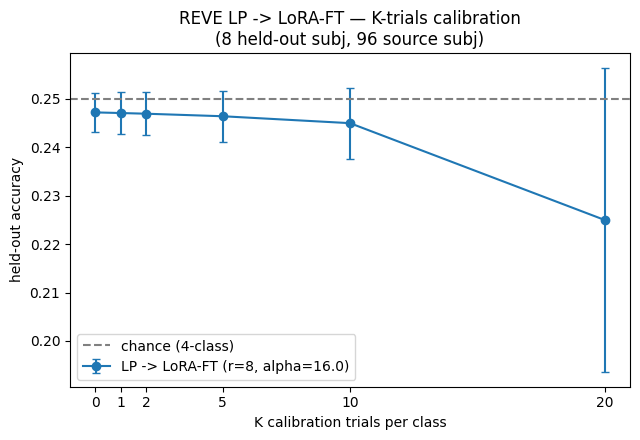

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.errorbar(summary["k"], summary["acc_mean"], yerr=summary["sem"],
             marker="o", capsize=3, label=f"LP -> LoRA-FT (r={LORA_RANK}, alpha={LORA_ALPHA})")
ax.axhline(0.25, ls="--", color="grey", label="chance (4-class)")
ax.set_xlabel("K calibration trials per class")
ax.set_ylabel("held-out accuracy")
ax.set_title(f"REVE LP -> LoRA-FT — K-trials calibration\n({len(held_out_subjects)} held-out subj, {len(source_subjects)} source subj)")
ax.set_xticks(list(K_BUDGETS))
ax.legend()
fig.tight_layout()
fig.show()

In [12]:
out_dir = REPO_ROOT / "results" / "reve_lora_finetune_nb"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
df.to_csv(out_dir / f"per_split_{stamp}.csv", index=False)
summary.to_csv(out_dir / f"summary_{stamp}.csv", index=False)
print("wrote:", out_dir)

wrote: /Users/williamtan/Projects/cs229/etm_clf/results/reve_lora_finetune_nb
